In [1]:
import sys, os, glob
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

HERE = Path(os.path.abspath(""))
ROOT = HERE.parent.parent if HERE.name == "clocking_tests" else HERE
sys.path.insert(0, str(ROOT))

from spacehub_calc import load_spacehub_data_live, TwoBodyOrbit

In [2]:
import subprocess
import concurrent.futures
import os

CLOCKING_DIR = str(HERE)
METHODS = ["AR_Radau", "BS", "Radau", "Sym6", "Sym10", "Sym6_Plus"]
INCLINATION = 5.0
TIMEOUT_S = 30 * 60  # 30 minutes per simulation

def run_method(m):
    try:
        result = subprocess.run(
            [f"./ct_{m}", str(INCLINATION)],
            cwd=CLOCKING_DIR, capture_output=True, text=True, timeout=TIMEOUT_S
        )
        return m, result.returncode, result.stdout
    except subprocess.TimeoutExpired:
        return m, -1, f"TIMED OUT after {TIMEOUT_S}s"

if False:
    # Compile all methods
    print("Compiling...")
    for m in METHODS:
        result = subprocess.run(
            ["g++", "-std=c++17", "-O3", "-pthread", f"inclined_{m}.cpp", "-o", f"ct_{m}"],
            cwd=CLOCKING_DIR, capture_output=True, text=True
        )
        print(f"  {m}: {'OK' if result.returncode == 0 else 'FAILED'}")
        if result.returncode != 0:
            print(result.stderr[:300])

    print("\nRunning simulations (30-min timeout each, 3 parallel workers)...")
    results = {}
    with concurrent.futures.ThreadPoolExecutor(max_workers=3) as executor:
        futures = {executor.submit(run_method, m): m for m in METHODS}
        for future in concurrent.futures.as_completed(futures):
            m, code, stdout = future.result()
            results[m] = (code, stdout)
            status = "DONE" if code == 0 else (f"TIMED OUT (>{TIMEOUT_S}s)" if code == -1 else f"FAILED (code {code})")
            print(f"  {m}: {status}")
            if code == 0:
                print(f"    {stdout.strip().splitlines()[-1]}")

In [3]:
# Filename conventions: inclination 5.0 is formatted as "5" by the C++ ostringstream default
incl_str = "5"

clock_logs = {m: f"{m}-clocktest-{incl_str}.log" for m in METHODS}
clock_dat  = {m: f"{m}-clocktest-{incl_str}.dat"  for m in METHODS}

print("Log files:", list(clock_logs.values()))
print("Dat files:", list(clock_dat.values()))

# Verify files exist
for m in METHODS:
    log_exists = os.path.exists(os.path.join(CLOCKING_DIR, clock_logs[m]))
    dat_exists = os.path.exists(os.path.join(CLOCKING_DIR, clock_dat[m]))
    print(f"  {m}: log={'✓' if log_exists else '✗'}  dat={'✓' if dat_exists else '✗'}")

Log files: ['AR_Radau-clocktest-5.log', 'BS-clocktest-5.log', 'Radau-clocktest-5.log', 'Sym6-clocktest-5.log', 'Sym10-clocktest-5.log', 'Sym6_Plus-clocktest-5.log']
Dat files: ['AR_Radau-clocktest-5.dat', 'BS-clocktest-5.dat', 'Radau-clocktest-5.dat', 'Sym6-clocktest-5.dat', 'Sym10-clocktest-5.dat', 'Sym6_Plus-clocktest-5.dat']
  AR_Radau: log=✓  dat=✓
  BS: log=✓  dat=✓
  Radau: log=✓  dat=✓
  Sym6: log=✓  dat=✓
  Sym10: log=✓  dat=✓
  Sym6_Plus: log=✓  dat=✓


In [4]:
def parse_log(log_path):
    """Parse a clocktest .log file.
    Returns dict with 'start' (str), 'checkpoints' (list of {sim_t, wall_t}),
    'elapsed_s' (float or None if timed out).
    """
    data = {"start": None, "checkpoints": [], "elapsed_s": None}
    try:
        with open(log_path) as f:
            for line in f:
                line = line.strip()
                if line.startswith("START"):
                    data["start"] = line[6:]
                elif line.startswith("CHECK"):
                    parts = line.split()
                    sim_t  = float(parts[1].split("=")[1])
                    wall_t = float(parts[2].split("=")[1].rstrip("s"))
                    data["checkpoints"].append({"sim_t": sim_t, "wall_t": wall_t})
                elif line.startswith("STOP"):
                    data["elapsed_s"] = float(line.split("=")[1].rstrip("s"))
    except FileNotFoundError:
        print(f"  Not found: {log_path}")
    return data

# Load all log data
log_data = {}
for m in METHODS:
    path = os.path.join(CLOCKING_DIR, clock_logs[m])
    log_data[m] = parse_log(path)
    d = log_data[m]
    elapsed = f"{d['elapsed_s']:.2f}s" if d["elapsed_s"] else "INCOMPLETE/TIMEOUT"
    print(f"{m}: start={d['start']}  checkpoints={len(d['checkpoints'])}  elapsed={elapsed}")

# Load orbital data from .dat files
orb_data = {}
for m in METHODS:
    path = os.path.join(CLOCKING_DIR, clock_dat[m])
    if os.path.exists(path):
        df = load_spacehub_data_live(path)
        orb_data[m] = TwoBodyOrbit.from_dataframe(df, i=0, j=1, mute=True)
        n = len(orb_data[m].years)
        print(f"{m}: {n} snapshots loaded (t_end = {orb_data[m].years[-1]:.0f} yr)")
    else:
        print(f"{m}: .dat file not found")

AR_Radau: start=2026-02-26 01:30:39  checkpoints=9  elapsed=INCOMPLETE/TIMEOUT
BS: start=2026-02-26 01:30:39  checkpoints=10  elapsed=0.70s
Radau: start=2026-02-26 01:30:39  checkpoints=10  elapsed=3.33s
Sym6: start=2026-02-26 01:30:40  checkpoints=10  elapsed=1.91s
Sym10: start=2026-02-26 01:30:42  checkpoints=9  elapsed=23.18s
Sym6_Plus: start=2026-02-26 01:30:42  checkpoints=10  elapsed=1.81s
Calculated c0 values are within 4.457e+04 of constant (maximum - minimum)
AR_Radau: 9948 snapshots loaded (t_end = 29841 yr)
Calculated c0 values are within 175.1 of constant (maximum - minimum)
BS: 10001 snapshots loaded (t_end = 30000 yr)
Calculated c0 values are within 175.1 of constant (maximum - minimum)
Radau: 10001 snapshots loaded (t_end = 30000 yr)
Calculated c0 values are within 175.1 of constant (maximum - minimum)
Sym6: 10001 snapshots loaded (t_end = 30000 yr)
Calculated c0 values are within 175.2 of constant (maximum - minimum)
Sym10: 10000 snapshots loaded (t_end = 29997 yr)
Calc

In [5]:
# --- Summary table ---
baseline = min(t for t in (d['elapsed_s'] for d in log_data.values()) if t is not None)
base_method = [m for m, d in log_data.items() if d['elapsed_s'] == baseline][0]

# Accuracy: RMS SMA deviation from reference solution (BS = adaptive, fast)
REF = "BS"
ref_t = np.asarray(orb_data[REF].years)
ref_sma = np.asarray(orb_data[REF].semiMajorAxis)

print(f"Baseline: {base_method} ({baseline:.2f}s)  |  Accuracy ref: {REF}\n")
print(f"{'Method':<12} {'Runtime':>10} {'Slowdown':>10} {'RMS ΔSMA (AU)':>15}")
print("-" * 50)
for m in METHODS:
    t = log_data[m]['elapsed_s']
    rt = f"{t:.2f}s" if t else "TIMEOUT"
    sd = f"{t/baseline:.1f}x" if t else "N/A"
    if m in orb_data:
        yrs = np.asarray(orb_data[m].years)
        sma = np.asarray(orb_data[m].semiMajorAxis)
        # interpolate reference onto this method's time grid
        ref_interp = np.interp(yrs, ref_t, ref_sma)
        rms = np.sqrt(np.mean((sma - ref_interp)**2))
        acc = f"{rms:.3f}" if m != REF else "(ref)"
    else:
        acc = "N/A"
    print(f"{m:<12} {rt:>10} {sd:>10} {acc:>15}")

Baseline: BS (0.70s)  |  Accuracy ref: BS

Method          Runtime   Slowdown   RMS ΔSMA (AU)
--------------------------------------------------
AR_Radau        TIMEOUT        N/A        1562.249
BS                0.70s       1.0x           (ref)
Radau             3.33s       4.8x           0.009
Sym6              1.91s       2.7x           0.013
Sym10            23.18s      33.1x           0.074
Sym6_Plus         1.81s       2.6x           0.013


In [6]:
COLORS = {"AR_Radau": "C0", "BS": "C1", "Radau": "C2", "Sym6": "C3", "Sym10": "C4", "Sym6_Plus": "C5"}
STOP_YR = 3e4  # t_stop in years (for reference)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# --- Left: bar chart of total elapsed time ---
ax = axes[0]
completed = {m: d["elapsed_s"] for m, d in log_data.items() if d["elapsed_s"] is not None}
timed_out = [m for m, d in log_data.items() if d["elapsed_s"] is None]

if completed:
    bars = ax.bar(list(completed.keys()), list(completed.values()),
                  color=[COLORS[m] for m in completed])
    for bar, (m, t) in zip(bars, completed.items()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05,
                f"{t:.3f}s", ha="center", va="bottom", fontsize=9)
for m in timed_out:
    ax.axhline(TIMEOUT_S, color="red", ls="--", lw=1)
    ax.text(0.5, TIMEOUT_S * 1.05, f"{m}: TIMEOUT (>{TIMEOUT_S}s)", transform=ax.get_xaxis_transform(),
            color="red", fontsize=8, ha="center")

ax.set_ylabel("Wall time (s)")
ax.set_title("Total elapsed time per integration method\n(t_stop = 3×10⁴ yr, SMA start = 5000 AU)")
ax.set_yscale("log")
ax.set_ylim(bottom=1e-3)

# --- Right: cumulative wall time at each checkpoint ---
ax = axes[1]
for m, d in log_data.items():
    checks = d["checkpoints"]
    if not checks:
        continue
    wall_t = [c["wall_t"] for c in checks]
    sim_yr = [c["sim_t"] / (2 * np.pi) for c in checks]
    pct = [100 * yr / STOP_YR for yr in sim_yr]
    ax.plot(pct, wall_t, "o-", label=m, color=COLORS[m])

ax.set_xlabel("Simulation progress (% of t_stop)")
ax.set_ylabel("Cumulative wall time (s)")
ax.set_title("Wall-clock time at each 10% checkpoint")
ax.legend(fontsize=9)
ax.set_yscale("log")
ax.set_ylim(bottom=1e-4)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

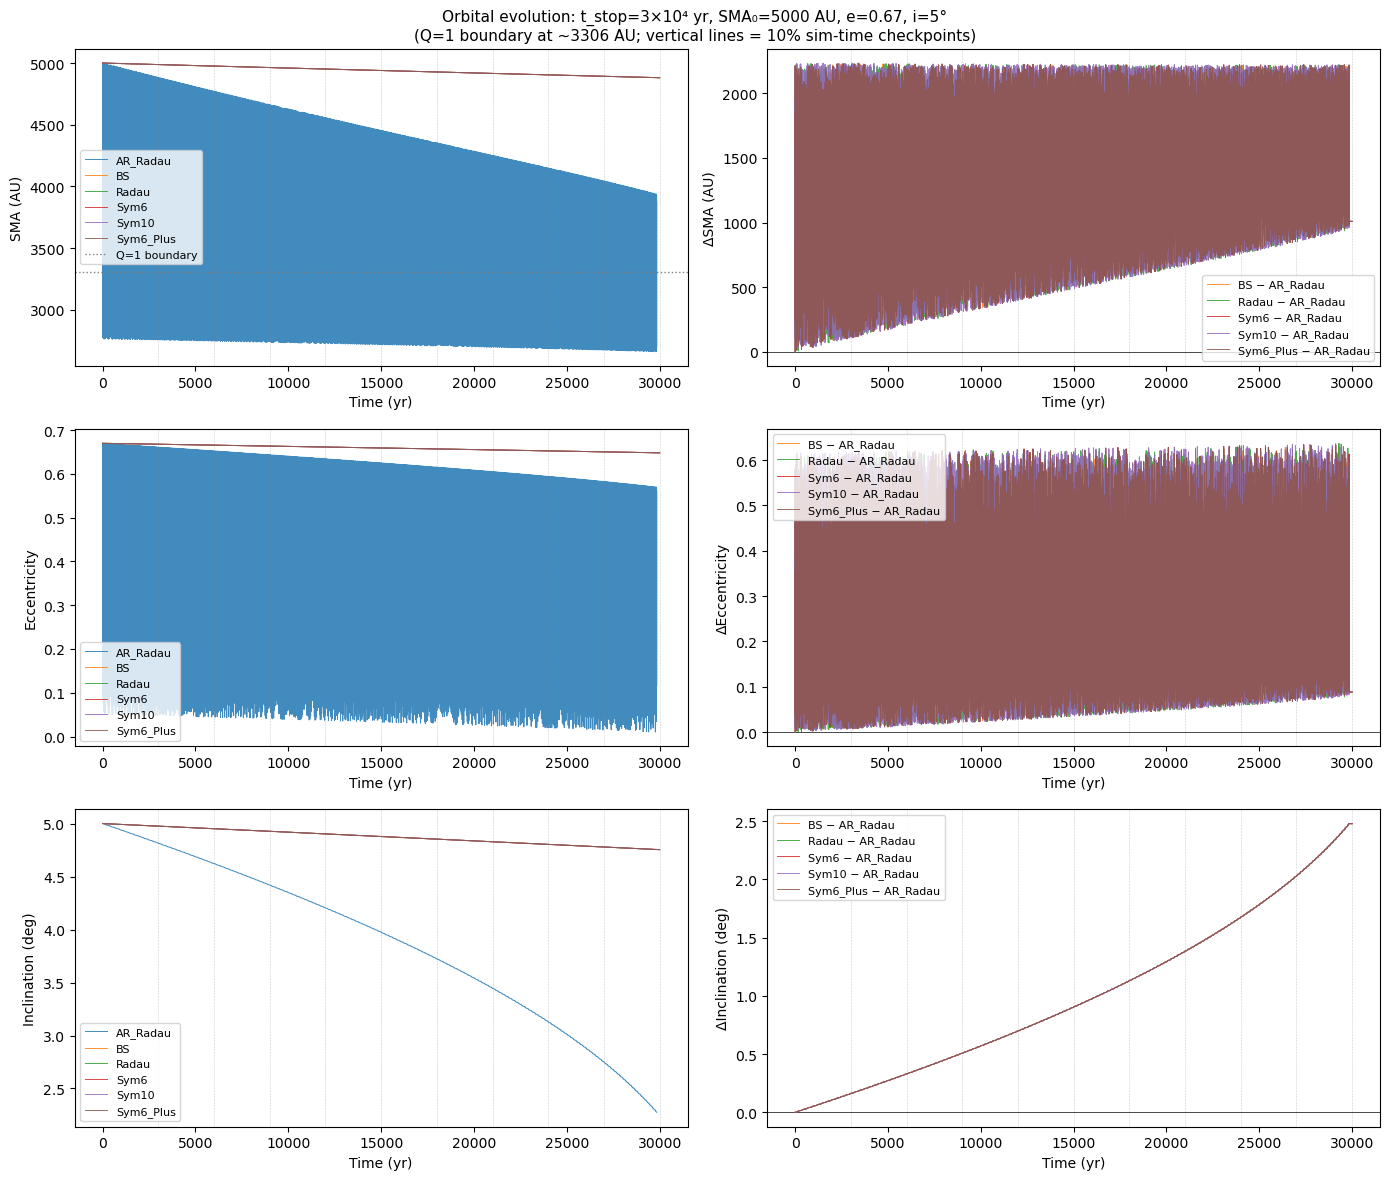

In [7]:
# Get checkpoint times in years for vertical reference lines
# Use the method with the most checkpoints as reference
ref_method = max(orb_data.keys(), key=lambda m: len(log_data[m]["checkpoints"])) if orb_data else "BS"
checkpoint_yr = [c["sim_t"] / (2 * np.pi) for c in log_data[ref_method]["checkpoints"]]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle(f"Orbital evolution: t_stop=3×10⁴ yr, SMA₀=5000 AU, e=0.67, i=5°\n"
             f"(Q=1 boundary at ~3306 AU; vertical lines = 10% sim-time checkpoints)", fontsize=11)

ELEM_ATTRS = [("semiMajorAxis",   "SMA (AU)",          None),
              ("eccentricity",    "Eccentricity",      None),
              ("inclination_deg", "Inclination (deg)", None)]

# Reference for residuals: use AR_Radau if available, else first method present
RESID_REF = "AR_Radau" if "AR_Radau" in orb_data else (list(orb_data.keys())[0] if orb_data else None)

for row, (attr, ylabel, transform) in enumerate(ELEM_ATTRS):
    ax_elem  = axes[row, 0]
    ax_resid = axes[row, 1]

    ref_years = None
    ref_vals  = None

    for m, orb in orb_data.items():
        years = np.asarray(orb.years)
        vals  = np.asarray(getattr(orb, attr))
        if transform is not None:
            vals = transform(vals)

        ax_elem.plot(years, vals, lw=0.7, alpha=0.85, label=m, color=COLORS[m])

        if m == RESID_REF:
            ref_years = years
            ref_vals  = vals

    # Draw horizontal reference line for Q=1 boundary SMA
    if attr == "semiMajorAxis":
        ax_elem.axhline(3306, color="gray", ls=":", lw=1, label="Q=1 boundary")

    # Checkpoint reference lines
    for yr in checkpoint_yr:
        ax_elem.axvline(yr, color="gray", lw=0.4, ls="--", alpha=0.4)
        ax_resid.axvline(yr, color="gray", lw=0.4, ls="--", alpha=0.4)

    ax_elem.set_xlabel("Time (yr)")
    ax_elem.set_ylabel(ylabel)
    ax_elem.legend(fontsize=8)

    # --- Residuals ---
    ax_resid.axhline(0, color="black", lw=0.5)
    if ref_years is not None:
        for m, orb in orb_data.items():
            if m == RESID_REF:
                continue
            years = np.asarray(orb.years)
            vals  = np.asarray(getattr(orb, attr))
            if transform is not None:
                vals = transform(vals)
            vals_ref = np.interp(years, ref_years, ref_vals)
            ax_resid.plot(years, vals - vals_ref, lw=0.7, alpha=0.85,
                          label=f"{m} − {RESID_REF}", color=COLORS[m])
        ax_resid.set_xlabel("Time (yr)")
        ax_resid.set_ylabel(f"Δ{ylabel}")
        ax_resid.legend(fontsize=8)
    else:
        ax_resid.text(0.5, 0.5, f"No reference data\n({RESID_REF} not available)",
                      ha="center", va="center", transform=ax_resid.transAxes)

plt.tight_layout()
plt.show()